In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from utils.data_manipulations import add_site_id

In [8]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from scipy.stats import linregress

In [9]:
from utils.visualisation_functions import *

In [10]:
def compute_shares(df, group_cols, path_col, value_col,
                   site_id_col=None, mode="aggregate"):
    """
    Compute shares of sub-groups (e.g. release pathways) within a higher-level group.

    Parameters
    ----------
    df : DataFrame
        Input data.

    group_cols : list of str
        Columns defining the higher-level grouping (e.g., ['mining_processing_type', 'substance_name']).

    path_col : str
        Column whose categories will form the stacked components (e.g., 'release_pathway').

    value_col : str
        Column containing values to aggregate (e.g., 'value', 'value_MJ', 'mass').

    site_id_col : str or None
        Identifier for individual sites if using site-level statistics.
        Required for mode="site_stats".

    mode : {"aggregate", "site_stats"}
        "aggregate" → ratio of sums (sum of shares = 1)
        "site_stats" → mean/min/max/std of site-level shares

    Returns
    -------
    DataFrame
        Shares (or statistics) for each group × sub-group.
    """

    df = df.copy()

    # ------------------------------
    # MODE 1: AGGREGATE SHARES
    # ------------------------------
    if mode == "aggregate":

        # Sum values for each group × pathway
        group_pathway = (
            df.groupby(group_cols + [path_col])[value_col]
            .sum()
            .rename("value_sum")
            .reset_index()
        )

        # Sum all pathways to get totals for each group
        total = (
            group_pathway.groupby(group_cols)["value_sum"]
            .sum()
            .rename("total_sum")
            .reset_index()
        )

        stats = group_pathway.merge(total, on=group_cols)
        stats["share"] = stats["value_sum"] / stats["total_sum"]

        return stats

    # ------------------------------
    # MODE 2: SITE-LEVEL STATISTICS
    # ------------------------------
    elif mode == "site_stats":

        if site_id_col is None:
            raise ValueError("site_id_col must be provided for mode='site_stats'")

        # Compute per-site totals
        site_totals = (
            df.groupby([site_id_col] + group_cols)[value_col]
            .sum()
            .rename("site_total")
            .reset_index()
        )

        df2 = df.merge(site_totals, on=[site_id_col] + group_cols)
        df2["share"] = df2[value_col] / df2["site_total"]

        stats = (
            df2.groupby(group_cols + [path_col])["share"]
            .agg(["mean", "min", "max", "std"])
            .reset_index()
        )

        return stats

    else:
        raise ValueError("mode must be 'aggregate' or 'site_stats'")


In [11]:
import matplotlib.pyplot as plt
import numpy as np
import os

def plot_stackplot_shares(stats_df,
                          group_cols,
                          path_col,
                          value_col=None,
                          mode="aggregate",
                          savepath=None,
                          figsize=(14,10),
                          dpi=300):
    """
    General stacked-bar share plot for aggregated or site-level statistics.

    Parameters
    ----------
    stats_df : DataFrame
        Output of compute_shares(), must already include shares or statistics.

    group_cols : list of str
        Columns defining groups (subplots × x-axis structure).
        Example: ['mining_processing_type', 'substance_name']

    path_col : str
        Column whose categories form the stacked bars.
        Example: 'release_pathway' or 'energy_group'.

    value_col : str or None
        Column to plot:
        - For mode="aggregate": typically 'share'
        - For mode="site_stats": typically 'mean'
        If None, uses:
            'share' for aggregate
            'mean' for site_stats

    mode : {"aggregate","site_stats"}
        Determines whether bars represent shares or mean site-level values.

    savepath : str or None
        Base path (no extension) for saving figure as PNG and SVG.

    Returns
    -------
    pivot_df : DataFrame
        Pivot table used for plotting.
    """

    df = stats_df.copy()

    # Choose plotting column
    if value_col is None:
        value_col = "share" if mode == "aggregate" else "mean"

    if value_col not in df.columns:
        raise ValueError(f"{value_col} not found in stats_df columns: {df.columns.tolist()}")

    df["plot_value"] = df[value_col]

    # Create pivot table dynamically based on group_cols
    pivot = df.pivot_table(
        index=group_cols,
        columns=path_col,
        values="plot_value",
        fill_value=0
    )

    # All stacked categories
    stack_categories = pivot.columns.tolist()

    # Unique subplot groups (based on the FIRST group_col)
    top_group = pivot.index.get_level_values(0).unique()

    # Colors
    colors = plt.get_cmap("tab20").colors[:len(stack_categories)]

    # Layout: 2 columns, enough rows for all groups
    ncols = 2
    nrows = int(np.ceil(len(top_group) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharey=True)
    axes = axes.flatten()

    # Iterate over mining_processing_types (or whatever top_group is)
    for ax, g in zip(axes, top_group):
        sub = pivot.loc[g]

        sub.plot(
            kind="bar",
            stacked=True,
            ax=ax,
            color=colors,
            edgecolor="black",
            width=0.85
        )

        ax.set_title(str(g), fontsize=14)
        ax.set_ylabel("Share in %", fontsize=12)
        ax.set_xlabel("")
        ax.set_ylim(0, 1)
        ax.tick_params(axis='x', labelsize=12)

        ax.legend().set_visible(False)

    # Hide unused axes
    for ax in axes[len(top_group):]:
        ax.set_visible(False)

    # Global legend
    fig.legend(
        stack_categories,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.08),
        ncol=min(len(stack_categories), 4),
        fontsize=12
    )

    plt.tight_layout()

    if savepath is not None:
        base = os.path.splitext(savepath)[0]
        fig.savefig(base + ".png", dpi=dpi, bbox_inches="tight")
        fig.savefig(base + ".svg", dpi=dpi, bbox_inches="tight")

    plt.show()

# Energy mix

In [12]:
df_energy = pd.read_excel(r'data/MetalliCan/pre_cleaned_data/energy_df.xlsx')
prod_data = pd.read_excel(r'data/MetalliCan/sites_for_lci.xlsx', sheet_name='prod_data')

In [13]:
df_energy = add_site_id(df_energy)
prod_data = add_site_id(prod_data)

In [14]:
df_energy = pd.merge(df_energy, prod_data[['site_id', 'mining_processing_type', 'archetypes', 'Main_product']], on='site_id', how='left')

In [15]:
remove = ['Energy use', 'Other', 'Acetylene', 'Ammonium nitrate']
df_energy = df_energy[~df_energy['subflow_type'].isin(remove)]

In [16]:
from utils.constants import nrj_subflow
df_energy['subflow_type_agg'] = df_energy['subflow_type'].map(nrj_subflow)

In [17]:
df_energy

,technosphere_id,year,flow_type,subflow_type,unit,value,comment,main_id,facility_group_id,company_id,...,value_MJ,unit_source,assumption_note,unit_standard,needs_factor,site_id,mining_processing_type,archetypes,Main_product,subflow_type_agg
1,TECH-857b7b89-2023.0-2.0,2023.0,Energy,Aviation fuel,GJ,72676.110790,NaN,BC-MAIN-857b7b89,<NA>,CMP-4a434d72,...,7.267611e+07,direct_unit,gj→MJ factor=1000.0,MJ,False,BC-MAIN-857b7b89,"Underground, concentrator",Hybrid free-milling-refactory,Au,Aviation fuel
2,TECH-857b7b89-2023.0-3.0,2023.0,Energy,Diesel,GJ,287042.447232,NaN,BC-MAIN-857b7b89,<NA>,CMP-4a434d72,...,2.870424e+08,direct_unit,gj→MJ factor=1000.0,MJ,False,BC-MAIN-857b7b89,"Underground, concentrator",Hybrid free-milling-refactory,Au,Diesel
3,TECH-857b7b89-2023.0-4.0,2023.0,Energy,Electricity consumption|Generated on-site,GJ,86225.117396,NaN,BC-MAIN-857b7b89,<NA>,CMP-4a434d72,...,8.622512e+07,direct_unit,gj→MJ factor=1000.0,MJ,False,BC-MAIN-857b7b89,"Underground, concentrator",Hybrid free-milling-refactory,Au,Electricity consumption|Generated on-site
4,TECH-857b7b89-2023.0-5.0,2023.0,Energy,Electricity consumption|Grid electricity,GJ,569009.584800,NaN,BC-MAIN-857b7b89,<NA>,CMP-4a434d72,...,5.690096e+08,direct_unit,gj→MJ factor=1000.0,MJ,False,BC-MAIN-857b7b89,"Underground, concentrator",Hybrid free-milling-refactory,Au,Electricity consumption|Grid electricity
5,TECH-857b7b89-2023.0-6.0,2023.0,Energy,Gasoline,GJ,13568.450000,NaN,BC-MAIN-857b7b89,<NA>,CMP-4a434d72,...,1.356845e+07,direct_unit,gj→MJ factor=1000.0,MJ,False,BC-MAIN-857b7b89,"Underground, concentrator",Hybrid free-milling-refactory,Au,Gasoline
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,TECH-7607a50e-2023.0-2.0,2023.0,Energy,Electricity consumption|Generated on-site,GJ,475.000000,NaN,ON-MAIN-7607a50e,<NA>,CMP-3a4ccc7f,...,4.750000e+05,direct_unit,gj→MJ factor=1000.0,MJ,False,ON-MAIN-7607a50e,"Underground, concentrator",Free-milling,Au,Electricity consumption|Generated on-site
156,TECH-7607a50e-2023.0-3.0,2023.0,Energy,Electricity consumption|Grid electricity,GJ,960748.000000,NaN,ON-MAIN-7607a50e,<NA>,CMP-3a4ccc7f,...,9.607480e+08,direct_unit,gj→MJ factor=1000.0,MJ,False,ON-MAIN-7607a50e,"Underground, concentrator",Free-milling,Au,Electricity consumption|Grid electricity
157,TECH-7607a50e-2023.0-4.0,2023.0,Energy,Gasoline,GJ,2124.000000,NaN,ON-MAIN-7607a50e,<NA>,CMP-3a4ccc7f,...,2.124000e+06,direct_unit,gj→MJ factor=1000.0,MJ,False,ON-MAIN-7607a50e,"Underground, concentrator",Free-milling,Au,Gasoline
158,TECH-7607a50e-2023.0-5.0,2023.0,Energy,Naphta,GJ,6344.000000,NaN,ON-MAIN-7607a50e,<NA>,CMP-3a4ccc7f,...,6.344000e+06,direct_unit,gj→MJ factor=1000.0,MJ,False,ON-MAIN-7607a50e,"Underground, concentrator",Free-milling,Au,Naphtha


In [18]:
nrj_mix_stats = compute_shares(
    df=df_energy,
    group_cols=["mining_processing_type", "Main_product"],
    path_col="subflow_type_agg",
    value_col="value_MJ",
    mode="aggregate"
)

In [19]:
nrj_mix_stats.to_csv(r'data/Parametrization/energy_mix_stats.csv', index=False)

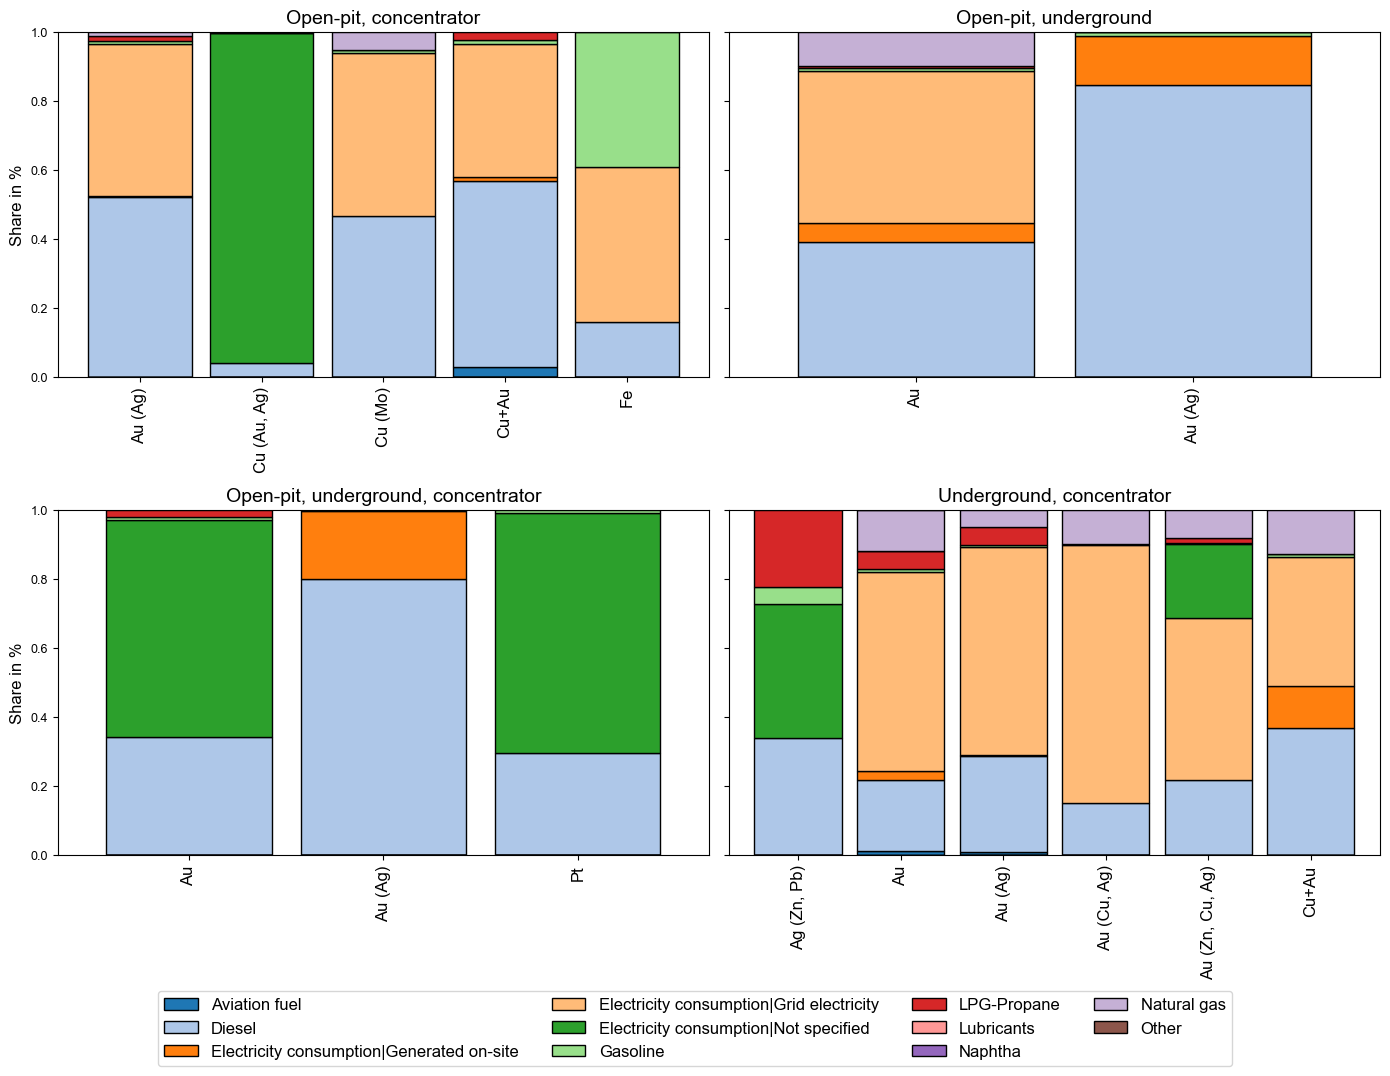

In [20]:
plot_stackplot_shares(
    stats_df=nrj_mix_stats,
    group_cols=["mining_processing_type", "Main_product"],
    path_col="subflow_type_agg",
    savepath=r'data/Parametrization/graphs/energy_mix',

)

# GHG

In [21]:
df_ghg = pd.read_csv(r'data/Quality control/ghg_flows.csv')
df_ghg = add_site_id(df_ghg)
df_ghg = pd.merge(df_ghg, prod_data[['site_id', 'mining_processing_type', 'archetypes', 'Main_product']], on='site_id', how='left')

In [22]:
df_ghg = df_ghg[df_ghg['release_pathway'] != 'Total']

In [23]:
substance_id_ghg_map = {
    '124-38-9': 'CO2',
    '74-82-8': 'CH4',
    '10024-97-2': 'N2O',
    'NA - GHG': 'CO2eq'
}
df_ghg['substance_name'] = df_ghg['substance_id'].map(substance_id_ghg_map)

In [24]:
df_ghg

,env_id,year,compartment_name,substance_id,flow_direction,release_pathway,unit,value,comment,main_id,facility_group_id,company_id,source_id,site_id,mining_processing_type,archetypes,Main_product,substance_name
0,GHG-10011-2023-1,2023,Air,124-38-9,Emission,Flaring / Torchage,tonnes,4.022000e+02,NaN,ON-MAIN-eab8c362,<NA>,CMP-0f9c0b53,https://www.canada.ca/en/environment-climate-c...,ON-MAIN-eab8c362,NaN,NaN,NaN,CO2
1,GHG-10011-2023-2,2023,Air,124-38-9,Emission,Stationary Fuel Combustion,tonnes,9.771639e+05,NaN,ON-MAIN-eab8c362,<NA>,CMP-0f9c0b53,https://www.canada.ca/en/environment-climate-c...,ON-MAIN-eab8c362,NaN,NaN,NaN,CO2
2,GHG-10011-2023-3,2023,Air,124-38-9,Emission,Industrial Processes,tonnes,3.276798e+06,NaN,ON-MAIN-eab8c362,<NA>,CMP-0f9c0b53,https://www.canada.ca/en/environment-climate-c...,ON-MAIN-eab8c362,NaN,NaN,NaN,CO2
3,GHG-10011-2023-4,2023,Air,124-38-9,Emission,On-site Transportation,tonnes,2.247158e+04,NaN,ON-MAIN-eab8c362,<NA>,CMP-0f9c0b53,https://www.canada.ca/en/environment-climate-c...,ON-MAIN-eab8c362,NaN,NaN,NaN,CO2
4,GHG-10013-2023-1,2023,Air,124-38-9,Emission,Stationary Fuel Combustion,tonnes,2.686400e+04,NaN,QC-MAIN-52c01ae4,<NA>,CMP-140e111b,https://www.canada.ca/en/environment-climate-c...,QC-MAIN-52c01ae4,NaN,NaN,NaN,CO2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
958,NaN,2023,Air,NA - GHG,Emission,Industrial Processes,tonnes,8.398070e+04,Aggregated value from multiple facilities,<NA>,GRP-de097f20,CMP-d5f1c66b,https://www.canada.ca/en/environment-climate-c...,GRP-de097f20,NaN,NaN,NaN,CO2eq
959,NaN,2023,Air,NA - GHG,Emission,Leakage / Fuites,tonnes,1.512000e+00,Aggregated value from multiple facilities,<NA>,GRP-de097f20,CMP-d5f1c66b,https://www.canada.ca/en/environment-climate-c...,GRP-de097f20,NaN,NaN,NaN,CO2eq
960,NaN,2023,Air,NA - GHG,Emission,On-site Transportation,tonnes,1.088594e+04,Aggregated value from multiple facilities,<NA>,GRP-de097f20,CMP-d5f1c66b,https://www.canada.ca/en/environment-climate-c...,GRP-de097f20,NaN,NaN,NaN,CO2eq
961,NaN,2023,Air,NA - GHG,Emission,Stationary Fuel Combustion,tonnes,3.953728e+04,Aggregated value from multiple facilities,<NA>,GRP-de097f20,CMP-d5f1c66b,https://www.canada.ca/en/environment-climate-c...,GRP-de097f20,NaN,NaN,NaN,CO2eq


In [25]:
ghg_mix_stats = compute_shares(
    df=df_ghg,
    group_cols=["mining_processing_type", "substance_name"],
    path_col="release_pathway",
    value_col="value",
    mode="aggregate"
)

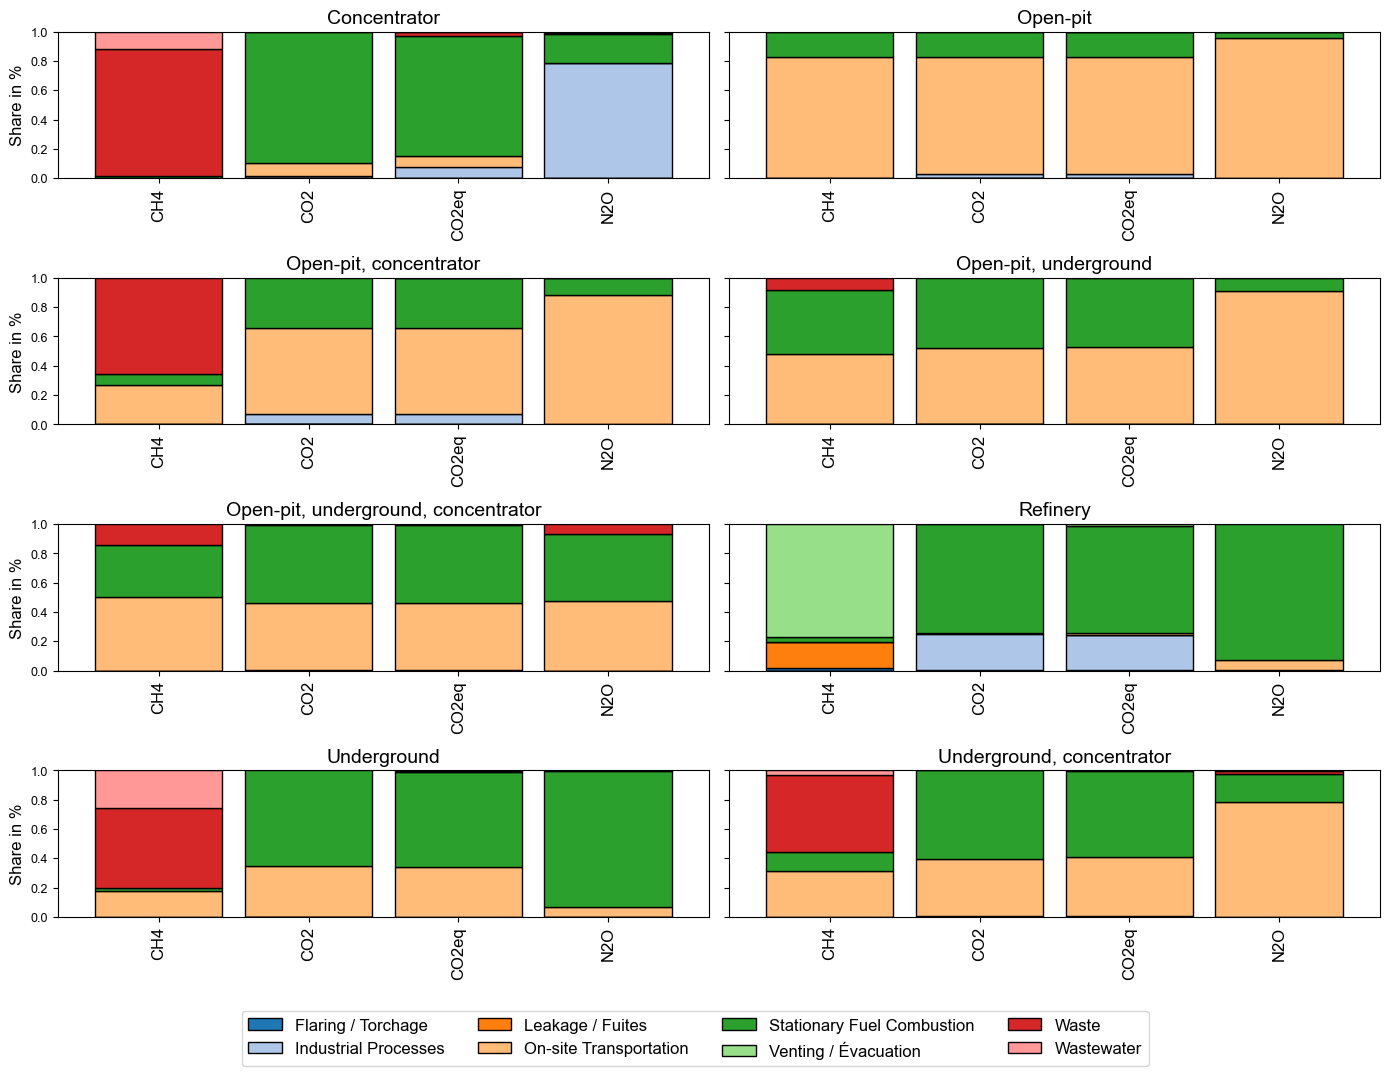

In [27]:
plot_stackplot_shares(
    stats_df=ghg_mix_stats,
    group_cols=["mining_processing_type", "substance_name"],
    path_col="release_pathway",
    savepath=r'data/Parametrization/graphs/ghg_mix',

)

# Material usage

In [19]:
df_material = pd.read_excel(r'data/SI/SI_LCIs_review.xlsx', sheet_name='Material_MetalliCan')

In [24]:
df = df_material

In [25]:
# Clean columns
df['associated_material_category'] = df['associated_material_category'].astype(str).str.strip()
df['mining_method'] = df['mining_method'].astype(str).str.strip()
df['archetype'] = df['archetype'].astype(str).str.strip()

# Remove extremely small or zero values that may break log and plotting (optional)
# df = df[df['value_normalized'] > 0]

# Create plot
fig = px.scatter(
    df,
    x="associated_material_category",
    y="value_normalized",
    color="archetype",
    symbol="mining_method",
    hover_data=["site_id", "archetype", "mining_method", "associated_material_category", "value_normalized"],
    title="Material Use per Category (Normalized per t ore)",
)

fig.update_layout(
    xaxis_title="Material Category",
    yaxis_title="Normalized Value (per t ore)",
    template="plotly_white",
    legend_title="Archetype",
    margin=dict(l=20, r=20, t=50, b=20)
)


In [22]:
# Clean category naming (optional)
df['associated_material_category'] = df['associated_material_category'].str.strip().str.replace(" ", "_")

# 1. Summary by material category
summary_cat = df.groupby('associated_material_category')['value_normalized'].agg(['min','max','mean','std']).reset_index()

# 2. Summary by mining method × category
summary_method = df.groupby(['mining_method','associated_material_category'])['value_normalized'].agg(['min','max','mean','std']).reset_index()

# 3. Summary by archetype × category
summary_arch = df.groupby(['archetype','associated_material_category'])['value_normalized'].agg(['min','max','mean','std']).reset_index()

# 4. Summary by mining method × archetype × category
summary_full = df.groupby(['mining_method','archetype','associated_material_category'])['value_normalized'].agg(['min','max','mean','std']).reset_index()

In [23]:
summary_full

,mining_method,archetype,associated_material_category,min,max,mean,std
0,"Open-pit, concentrator",Free-milling,explosives,2.647163e-03,2.647163e-03,2.647163e-03,NaN
1,"Open-pit, underground",Free-milling,acid,3.160426e-09,9.218310e-07,3.385893e-07,5.069983e-07
2,"Open-pit, underground",Free-milling,cement,4.320852e-03,4.320852e-03,4.320852e-03,NaN
3,"Open-pit, underground",Free-milling,consuming_equipment,2.153843e-04,2.153843e-04,2.153843e-04,NaN
4,"Open-pit, underground",Free-milling,cyanide,2.523260e-04,2.523260e-04,2.523260e-04,NaN
5,"Open-pit, underground",Free-milling,grinding_media,6.637657e-04,6.637657e-04,6.637657e-04,NaN
6,"Open-pit, underground",Free-milling,lubricant,1.872353e-04,1.872353e-04,1.872353e-04,NaN
7,"Open-pit, underground",Free-milling,ph_modifier,1.493274e-03,1.493274e-03,1.493274e-03,NaN
8,"Open-pit, underground, concentrator",Free-milling,anti_scalant,2.638519e-05,2.638519e-05,2.638519e-05,NaN
9,"Open-pit, underground, concentrator",Free-milling,cyanide,2.589651e-04,2.589651e-04,2.589651e-04,NaN


In [26]:
summary_full.to_csv(r'data/Parametrization/material_usage_summary.csv', index=False)

# Quantity vs land occupation

In [28]:
import numpy as np
import itertools
from scipy.stats import linregress
import plotly.graph_objects as go
import plotly.express as px

def plot_land_vs_ore(
    df,
    x_col="ore_processed_t",
    y_col="land_data",
    product_col="Main_product",
    label_col="facility_name",
    symbol_col="mining_processing_type",
    x_abs="Land occupation (m²)",
    y_abs="Ore processed (t)",
    output_html="land_vs_ore_plot.html",
    log_x=False,
    log_y=False,
):
    """
    Plot land use vs ore processed with:
    - symbol = mining_processing_type (black symbol legend)
    - color = Main_product (color legend)
    - linear regression fit y = a*x + b

    Parameters
    ----------
    df : DataFrame
        Must include columns:
        [x_col, y_col, product_col, label_col, symbol_col]

    x_col : str
        Column with land data (m²).
    y_col : str
        Column with ore processed (t).

    log_x, log_y : bool
        If True, use logarithmic axis for x and/or y (no change in the fit;
        it stays linear in normal space, only axes change).
    """

    # Filter valid rows
    df_plot = df[(df[x_col] > 0) & (df[y_col] > 0)].copy()
    if df_plot.empty:
        raise ValueError("No positive values found for x_col and y_col after filtering.")

    # ---------- Linear fit in normal space ----------
    x = df_plot[x_col].astype(float)
    y = df_plot[y_col].astype(float)

    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = intercept + slope * x_line

    # ---------- Symbol mapping (mining_processing_type) ----------
    symbol_categories = df_plot[symbol_col].astype("category")
    df_plot["_symbol_code"] = symbol_categories.cat.codes
    symbol_map = dict(enumerate(symbol_categories.cat.categories))

    # ---------- Color mapping (Main_product) ----------
    pastel_palette = px.colors.qualitative.Pastel
    products = df_plot[product_col].unique()
    color_cycle = itertools.cycle(pastel_palette)
    product_to_color = {p: next(color_cycle) for p in products}

    fig = go.Figure()

    # ---------------------------------------------------------
    # 1) MINING TYPE LEGEND  (symbols ONLY, black)
    # ---------------------------------------------------------
    for code, name in symbol_map.items():
        fig.add_trace(go.Scatter(
            x=[None], y=[None],
            mode="markers",
            marker=dict(symbol=code, size=12, color="black"),
            name=f"{name}",
            legendgroup="mining",
            showlegend=True
        ))

    # ---------------------------------------------------------
    # 2) MAIN PRODUCT LEGEND (colors ONLY, fixed symbol)
    # ---------------------------------------------------------
    for product in products:
        fig.add_trace(go.Scatter(
            x=[None], y=[None],
            mode="markers",
            marker=dict(
                symbol="circle",
                size=12,
                color=product_to_color[product],
                line=dict(color="black", width=1)
            ),
            name=f"{product}",
            legendgroup="product",
            showlegend=True
        ))

    # ---------------------------------------------------------
    # 3) REAL DATA POINTS  (symbol = mining, color = product)
    # ---------------------------------------------------------
    for _, row in df_plot.iterrows():
        fig.add_trace(go.Scatter(
            x=[row[x_col]],
            y=[row[y_col]],
            mode="markers",
            name=row[product_col],
            legendgroup="data",
            showlegend=False,
            marker=dict(
                symbol=row["_symbol_code"],
                color=product_to_color[row[product_col]],
                size=11,
                line=dict(color="black", width=1)
            ),
            text=row[label_col],
            hovertemplate=(
                f"Facility: {row[label_col]}<br>"
                f"{x_abs}: {row[x_col]:,.0f}<br>"
                f"{y_abs}: {row[y_col]:,.0f}"
            ),
        ))

    # ---------------------------------------------------------
    # 4) LINEAR FIT CURVE
    # ---------------------------------------------------------
    fig.add_trace(go.Scatter(
        x=x_line,
        y=y_line,
        mode="lines",
        name="Fit: y = {:.2e} × x + {:.2e}<br>R² = {:.2f}".format(
            slope, intercept, r_value**2
        ),
        line=dict(color="black", width=2),
        legendgroup="fit",
        showlegend=True
    ))

    # ---------------------------------------------------------
    # Layout
    # ---------------------------------------------------------
    fig.update_layout(
        title="",
        xaxis_title=x_abs,
        yaxis_title=y_abs,
        paper_bgcolor="white",
        plot_bgcolor="white",
        font=dict(color="black"),
        legend=dict(
            bgcolor="rgba(0,0,0,0)",
            groupclick="toggleitem"
        ),
        xaxis=dict(
            gridcolor="lightgray",
            type="log" if log_x else "linear"
        ),
        yaxis=dict(
            gridcolor="lightgray",
            rangemode="tozero",
            tickformat='d',
            type="log" if log_y else "linear"
        )
    )

    fig.write_html(output_html)
    fig.show()


In [29]:
# Outliers removal
#prod_data_t = prod_data[prod_data['facility_name'] != 'Highland Valley']

In [30]:
ug = prod_data[prod_data['mining_processing_type'].isin(['Underground, concentrator', 'Underground'])]
op = prod_data[prod_data['mining_processing_type'].isin(['Open-pit, concentrator', 'Open-pit', 'Open-pit, underground', 'Open-pit, underground, concentrator'])]
#both = prod_data[prod_data['mining_processing_type'].isin(['Open-pit, underground', 'Open-pit, underground, concentrator'])]

In [31]:
# Outliers removal
op = op[op['facility_name'] != 'Highland Valley']

In [35]:
plot_land_vs_ore(
    ug,
    x_col="ore_processed_t",
    y_col="land_data?",
    product_col="Main_product",
    label_col="facility_name",
    symbol_col="mining_processing_type",
    x_abs="Ore processed (t/year)",
    y_abs="Land footprint (m²)",
    log_x=False,
    log_y=False,
    output_html='data/Parametrization/land_vs_ore_ug.html'
)


In [36]:
plot_land_vs_ore(
    op,
    x_col="ore_processed_t",
    y_col="land_data?",
    product_col="Main_product",
    label_col="facility_name",
    symbol_col="mining_processing_type",
    x_abs="Ore processed (t/year)",
    y_abs="Land footprint (m²)",
    log_x=False,  # you can try True/False depending on spread
    log_y=False,
    output_html='data/Parametrization/land_vs_ore_open_pit.html'
)

# Grade

## Import data

In [21]:
biosphere_df = pd.read_csv(r'data/MetalliCan/data_for_lci_initialization/economic_allocation/biosphere_df.csv')
water_df = biosphere_df[biosphere_df['substance_name'] == 'Water']

In [22]:
substance_of_interest = ['Lead (and its compounds)', 'Arsenic (and its compounds)', 'Cobalt (and its compounds)', 'Cadmium (and its compounds)', 'Copper (and its compounds)', 'Zinc (and its compounds)', 'Manganese (and its compounds)']

In [23]:
npri_df = biosphere_df[biosphere_df['substance_name'].isin(substance_of_interest)]

In [24]:
npri_df = add_site_id(npri_df)

In [25]:
npri_df.rename(columns={'unit': 'unit_substance'}, inplace=True)

In [26]:
energy_df_metal = pd.read_csv(r'data/MetalliCan/data_for_lci_initialization/economic_allocation/energy_df.csv')
energy_df_ore = pd.read_csv(r'data/MetalliCan/data_for_lci_initialization/ore_normalization/energy_df.csv')
ta_df = pd.read_csv(r'data/MetalliCan/pre_cleaned_data/ta_table.csv')
material_nrj = pd.read_csv(r'C:\Users\mp_ma\OneDrive - polymtl\POST_DOC\CODE\metallican_db\database\CSV\materials_energy_table.csv')
prod_data = pd.read_excel(r'data/MetalliCan/sites_for_lci.xlsx', sheet_name='prod_data')

In [27]:
prod_data = add_site_id(prod_data)
material_nrj_table = add_site_id(material_nrj)

In [28]:
# Let's exclude the mines for which we don't know if Au or others are the main product
multiple_com_mines = ['BC-MAIN-599152a0', 'BC-MAIN-6b4800fe', 'ON-MAIN-f8313ebd', 'BC-MAIN-ed23117f', 'BC-MAIN-aa76f6f2', 'BC-MAIN-8eb8be0d', 'QC-MAIN-a97821c0',
'MB-MAIN-e0a6250e', 'NL-MAIN-2d8801d6'] # Copper Mountain, Gibraltar + Kidd Creek, Mount Milligan, New Afton, Red Chris, Raglan, Thompson, Voisey's Bay, Nunanick Nickel, Snow Lake ('GRP-a13779f8')
cu_mines = ['BC-MAIN-599152a0', 'BC-MAIN-6b4800fe'] # Copper Mountain, Gibraltar
fe_mines = ['NL-MAIN-dd723db4'] # Carol Lake
ag_mines = ['YT-MAIN-44857446'] # Keno Hill
pt_mines = ['ON-MAIN-a3c56a83'] # Lac des Iles

In [29]:
unique_to_ta = ta_df[~ta_df['site_id'].isin(material_nrj_table['site_id'])]['site_id'].unique()
unique_to_ta

array(['QC-MAIN-089f3c60', 'ON-MAIN-de2f9639', 'ON-MAIN-52224e1e',
       'BC-MAIN-4724f4ba', 'ON-MAIN-4e0734b5', 'ON-MAIN-48fe2205',
       'BC-MAIN-bf503b6b', 'ON-MAIN-f8313ebd', 'MB-MAIN-be5b3dc8',
       'ON-MAIN-8825d90d', 'ON-MAIN-7001a391', 'BC-MAIN-3f490561',
       'MB-MAIN-da0b5c3d', 'MB-MAIN-0898e255', 'ON-MAIN-f4fc3276',
       'AB-MAIN-d3a4aba9', 'ON-MAIN-28f3f0fc'], dtype=object)

In [30]:
unique_to_mat_nrj = material_nrj_table[~material_nrj_table['site_id'].isin(ta_df['site_id'])]['site_id'].unique()
unique_to_mat_nrj

array(['NL-MAIN-b64bae7a', 'NL-MAIN-dd723db4'], dtype=object)

## Data treatment

In [31]:
energy_df_au = energy_df_metal[~energy_df_metal['site_id'].isin(multiple_com_mines+cu_mines+fe_mines+ag_mines+pt_mines)]
energy_df_ore = energy_df_ore[~energy_df_ore['site_id'].isin(multiple_com_mines+cu_mines+fe_mines+ag_mines+pt_mines)]
ta_df_au = ta_df[~ta_df['site_id'].isin(multiple_com_mines+cu_mines+fe_mines+ag_mines+pt_mines)]
npri_df_au = npri_df[~npri_df['site_id'].isin(multiple_com_mines+cu_mines+fe_mines+ag_mines+pt_mines)]
water_df_au = water_df[~water_df['site_id'].isin(multiple_com_mines+cu_mines+fe_mines+ag_mines+pt_mines)]

In [32]:
# energy_df = energy_df[energy_df['site_id'].isin(multiple_com_mines)]
# ta_df = ta_df[ta_df['site_id'].isin(multiple_com_mines)]

In [33]:
grades_df_au = ta_df_au[ta_df_au['material_type'].str.contains('grade', case=False, na=False)].copy()
grades_df_au = grades_df_au[grades_df_au['material_type']!='Concentrate grade']
grades_df_au['grade_percent'] = grades_df_au.apply(lambda row: row['value'] * 0.0001 if 'g/t' in str(row['unit']).lower() else row['value'], axis=1)

In [34]:
# grades_df_cu = ta_df_cu[ta_df_cu['material_type'].str.contains('grade', case=False, na=False)].copy()
# grades_df_cu = grades_df_cu[grades_df_cu['material_type']!='Concentrate grade']
# grades_df_cu['grade_percent'] = grades_df_cu.apply(lambda row: row['value'] * 0.0001 if 'g/t' in str(row['unit']).lower() else row['value'], axis=1)

In [35]:
# grades_df = ta_df[ta_df['material_type'].str.contains('grade', case=False, na=False)].copy()
# grades_df = grades_df_cu[grades_df['material_type']!='Concentrate grade']
# grades_df['grade_percent'] = grades_df.apply(lambda row: row['value'] * 0.0001 if 'g/t' in str(row['unit']).lower() else row['value'], axis=1)

In [36]:
energy_total_au = (energy_df_au.groupby('site_id', as_index=False)['value_normalized'].sum().rename(columns={'value_normalized': 'total_energy_normalized'}))
energy_total_ore = (energy_df_ore.groupby('site_id', as_index=False)['value_normalized'].sum().rename(columns={'value_normalized': 'total_energy_normalized'}))
# energy_total_cu = (energy_df_cu.groupby('site_id', as_index=False)['value_normalized'].sum().rename(columns={'value_normalized': 'total_energy_normalized'}))
# energy_total = (energy_df.groupby('site_id', as_index=False)['value_normalized'].sum().rename(columns={'value_normalized': 'total_energy_normalized'}))

In [37]:
npri_df_au = npri_df_au[npri_df_au['metal'] == 'Au']
water_df_au = water_df_au[water_df_au['metal'] == 'Au']

In [38]:
df_au_nrj = pd.merge(grades_df_au[['site_id', 'commodity', 'material_type', 'facility_name', 'unit', 'value', 'grade_percent']],
                     energy_total_au,
                     on='site_id',
                     how='left')
df_au_nrj = pd.merge(df_au_nrj, prod_data[['site_id', 'mining_processing_type', 'Main_product']], on='site_id', how='left')
df_au_nrj = df_au_nrj[df_au_nrj['commodity'] == 'Gold']
df_au_nrj['total_energy_normalized'] = df_au_nrj['total_energy_normalized'] / 1000 # To have in GJ/t Au


In [39]:
df_au_npri = pd.merge(grades_df_au[['site_id', 'commodity', 'material_type', 'facility_name', 'unit', 'value', 'grade_percent']],
                      npri_df_au[['site_id', 'facility_group_id', 'compartment_name', 'substance_name', 'flow_direction', 'release_pathway', 'unit_substance', 'value_normalized']],
                      on='site_id',
                      how='left')
df_au_npri = pd.merge(df_au_npri, prod_data[['site_id', 'mining_processing_type', 'Main_product']], on='site_id', how='left')
df_au_npri = df_au_npri[df_au_npri['commodity'] == 'Gold']


In [40]:
water_df_au = water_df_au[water_df_au['flow_direction'] == 'Consumption']

In [41]:
# Remove rows where the value_normalized is negative
water_df_au = water_df_au[water_df_au['value_normalized'] >= 0]

In [42]:
df_au_water = pd.merge(grades_df_au[['site_id', 'commodity', 'material_type', 'facility_name', 'unit', 'value', 'grade_percent']],
                      water_df_au[['site_id', 'value_normalized']],
                      on='site_id',
                      how='left')
df_au_water = pd.merge(df_au_water, prod_data[['site_id', 'mining_processing_type', 'Main_product']], on='site_id', how='left')
df_au_water = df_au_water[~df_au_water['value_normalized'].isna()]
df_au_water = df_au_water[df_au_water['commodity'] == 'Gold']

In [43]:
# df_ore = pd.merge(grades_df_au[['site_id', 'commodity', 'material_type', 'facility_name', 'unit', 'value', 'grade_percent']],
#                   energy_total_ore,
#                   on='site_id',
#                   how='left')
# df_ore = pd.merge(df_ore, prod_data[['site_id', 'mining_processing_type', 'Main_product']], on='site_id', how='left')
# df_ore = df_ore[df_ore['commodity'] == 'Gold']

In [44]:
# df_cu = pd.merge(grades_df_cu[['site_id', 'commodity', 'material_type', 'facility_name', 'grade_percent']], energy_total_cu, on='site_id', how='left')
# df_cu = pd.merge(df_cu, prod_data[['site_id', 'Main_product']], on='site_id', how='left')
# df_cu = df_cu[df_cu['commodity'] == 'Copper']

In [45]:
# df = pd.merge(grades_df[['site_id', 'commodity', 'material_type', 'facility_name', 'grade_percent']], energy_total, on='site_id', how='left')
# df = pd.merge(df_cu, prod_data[['site_id', 'Main_product']], on='site_id', how='left')
# df = df[df['commodity'] == 'Copper']

In [46]:
df_au_npri = df_au_npri[df_au_npri['facility_name'] != 'Timmins West' ]

In [47]:
df_au_npri["value_normalized"] = df_au_npri.groupby(["site_id", "compartment_name", "substance_name", "flow_direction"])["value_normalized"].transform("sum")
df_au_npri = df_au_npri.drop(columns=["release_pathway"]).drop_duplicates()

In [48]:
df_au_npri_arsenic = df_au_npri[df_au_npri['substance_name'] == 'Arsenic (and its compounds)']
df_au_npri_cadmium = df_au_npri[df_au_npri['substance_name'] == 'Cadmium (and its compounds)']
df_au_npri_cobalt = df_au_npri[df_au_npri['substance_name'] == 'Cobalt (and its compounds)']
df_au_npri_copper = df_au_npri[df_au_npri['substance_name'] == 'Copper (and its compounds)']
df_au_npri_lead = df_au_npri[df_au_npri['substance_name'] == 'Lead (and its compounds)']
df_au_npri_manganese = df_au_npri[df_au_npri['substance_name'] == 'Manganese (and its compounds)']
df_au_npri_zinc = df_au_npri[df_au_npri['substance_name'] == 'Zinc (and its compounds)']

In [49]:
df_au_nrj.to_csv(r'data/Parametrization/au_nrj_relationship.csv', index=False)
df_au_npri.to_csv(r'data/Parametrization/au_npri_relationship.csv', index=False)
df_au_water.to_csv(r'data/Parametrization/au_water_relationship.csv', index=False)

## Plotting

In [53]:
df_au_nrj_t = df_au_nrj[df_au_nrj['facility_name'] != 'Eagle River']
df_au_water_t = df_au_water[df_au_water['facility_name'] != 'Eagle River']

In [51]:
plot_grade_relationship(df_au_nrj_t, x_col='value', y_abs='GJ/t Au', output_html='data/Parametrization/au_nrj_relationship_without_outliers.html')

In [52]:
#plot_grade_relationship(df_au_nrj, x_col='value', y_abs='GJ/t Au', output_html='data/Parametrization/au_nrj_relationship.html')


In [54]:
plot_grade_relationship(df_au_water_t, x_col='value', y_col='value_normalized', y_abs='m3/t Au', output_html='data/Parametrization/au_water_relationship_without_outliers.html')

In [46]:
plot_grade_relationship(df_au_npri_arsenic, x_col='value', y_col='value_normalized', y_abs='kg Arsenic/t Au', output_html='data/Parametrization/au_arsenic_relationship.html')

In [47]:
plot_grade_relationship(df_au_npri_cadmium, x_col='value', y_col='value_normalized', y_abs='kg Cadmium/t Au', output_html='data/Parametrization/au_cadmium_relationship.html')